In [1]:
import sys

sys.path.append("..")

import matplotlib.pyplot as plt
import numpy as np

In [2]:
from candidate.candidate import Candidate
from voter.voter import Voter
from election.election import Election
from election.result import ElectionResult
from analysis.analyzer import ResultsAnalyzer

from strategy.strategy import VotingStrategy
from strategy.plurality import PluralityStrategy
from strategy.borda import BordaCountStrategy
from strategy.veto import VetoStrategy

from visualization.util import (
    plot,
    plot_results,
    random_2d_points,
    random_2d_point,
    plot_winner_distance_histogram,
)

In [3]:
from collections import defaultdict

strategies = [PluralityStrategy(), BordaCountStrategy()]

C_values = [5, 10, 25, 50, 100]
V_values = [25, 50, 100, 200, 500]
N_CONFIGS = 20  # candidate configurations per (C, V)
N_VOTER_SAMPLES = 10  # voter draws per candidate configuration

# nested_results[(C, V)] = list of groups; each group = list of ElectionResult
# sharing one candidate configuration but different voter draws
nested_results: dict[tuple, list[list[ElectionResult]]] = defaultdict(list)

for C in C_values:
    for V in V_values:
        for _ in range(N_CONFIGS):
            candidates = [
                Candidate(id=id, position=random_2d_point()) for id in range(C)
            ]

            group: list[ElectionResult] = []
            for _ in range(N_VOTER_SAMPLES):
                voters = [Voter(position=random_2d_point()) for _ in range(V)]
                election = Election(candidates=candidates, voters=voters)
                group.append(election.compare_strategies(strategies=strategies))

            nested_results[(C, V)].append(group)

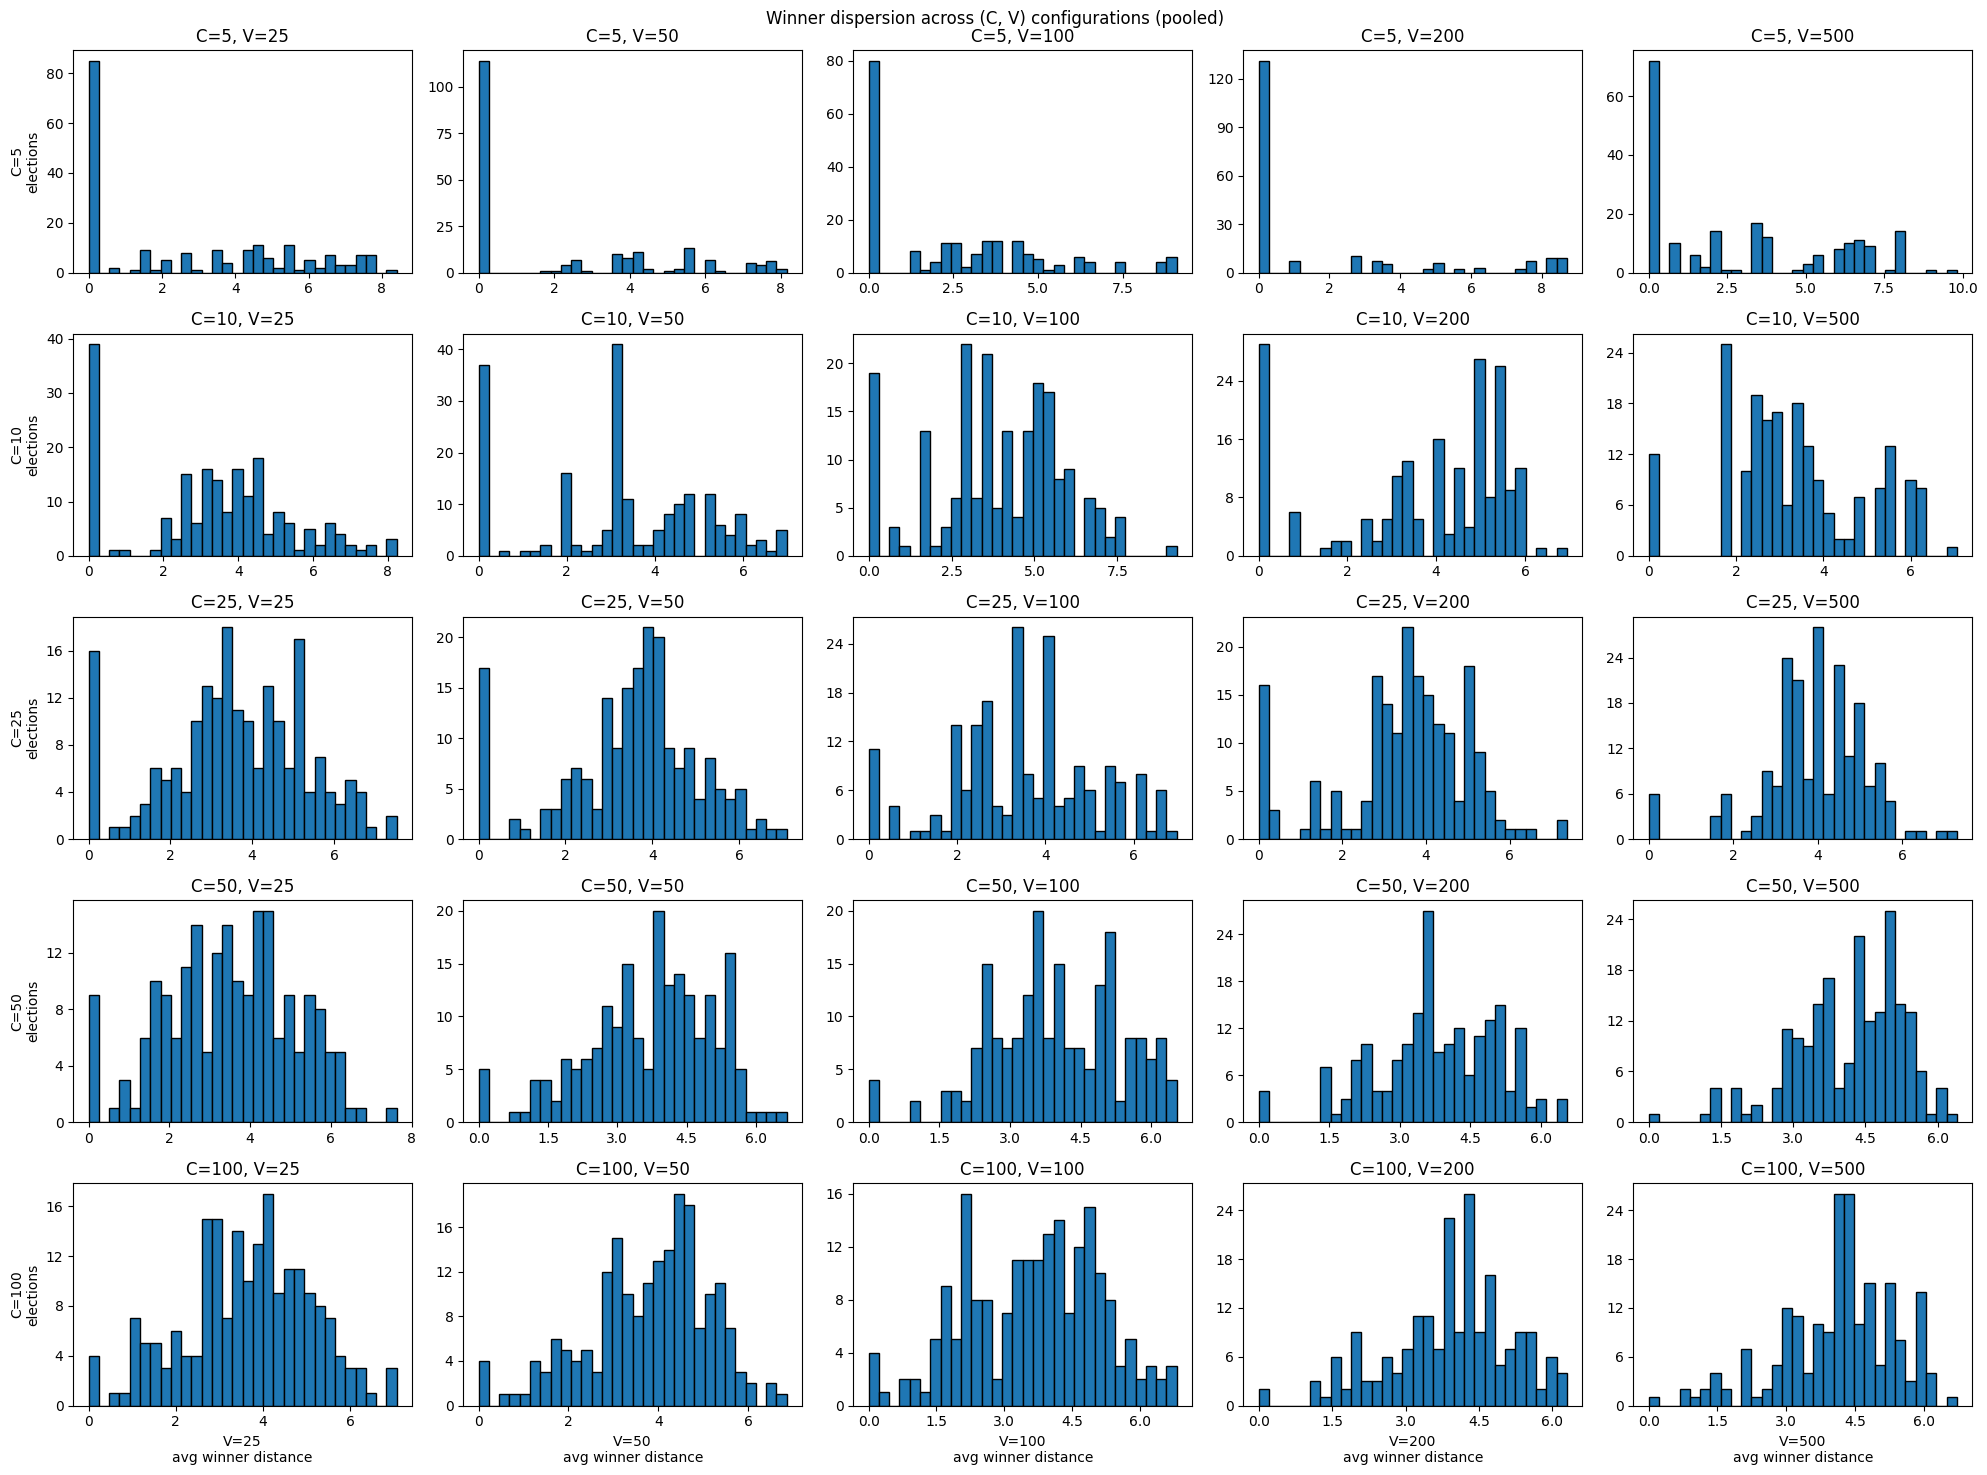

In [4]:
fig, axes = plt.subplots(
    len(C_values),
    len(V_values),
    figsize=(4 * len(V_values), 3 * len(C_values)),
    squeeze=False,
)

for i, C in enumerate(C_values):
    for j, V in enumerate(V_values):
        ax = axes[i][j]
        flat = [r for group in nested_results[(C, V)] for r in group]
        distances = ResultsAnalyzer(flat).winner_distance_series()

        plot_winner_distance_histogram(distances=distances, bins=30, ax=ax)
        ax.set_title(f"C={C}, V={V}")
        ax.set_xlabel("")
        ax.set_ylabel("")

for i, C in enumerate(C_values):
    axes[i][0].set_ylabel(f"C={C}\nelections")
for j, V in enumerate(V_values):
    axes[-1][j].set_xlabel(f"V={V}\navg winner distance")

fig.suptitle("Winner dispersion across (C, V) configurations (pooled)")
fig.tight_layout()
plt.show()

In [5]:
# Variance decomposition per (C, V):
# - between: std of per-config means (sensitivity to candidate placement)
# - within:  mean of per-config stds  (sensitivity to voter draw, candidates fixed)
print(f"{'C':>5} {'V':>5} {'mean':>8} {'between':>9} {'within':>8}")
for C in C_values:
    for V in V_values:
        groups = nested_results[(C, V)]
        per_config_means = [
            float(np.mean(ResultsAnalyzer(g).winner_distance_series())) for g in groups
        ]
        per_config_stds = [
            float(np.std(ResultsAnalyzer(g).winner_distance_series())) for g in groups
        ]
        print(
            f"{C:>5} {V:>5} "
            f"{np.mean(per_config_means):>8.3f} "
            f"{np.std(per_config_means):>9.3f} "
            f"{np.mean(per_config_stds):>8.3f}"
        )

    C     V     mean   between   within
    5    25    2.705     1.445    2.202
    5    50    2.116     1.743    1.626
    5   100    2.519     1.425    1.852
    5   200    1.850     2.041    1.651
    5   500    2.995     2.340    1.345
   10    25    3.341     0.868    1.786
   10    50    3.208     0.818    1.677
   10   100    3.888     1.013    1.492
   10   200    3.729     1.430    1.143
   10   500    3.349     1.394    0.451
   25    25    3.596     0.435    1.577
   25    50    3.533     0.542    1.386
   25   100    3.502     0.822    1.251
   25   200    3.475     0.494    1.310
   25   500    3.940     0.578    0.938
   50    25    3.508     0.553    1.449
   50    50    3.718     0.399    1.257
   50   100    3.978     0.567    1.217
   50   200    3.804     0.765    0.960
   50   500    4.185     0.565    0.866
  100    25    3.634     0.419    1.357
  100    50    3.793     0.481    1.209
  100   100    3.653     0.587    1.299
  100   200    3.911     0.553    1.078
